# Homework 5 Completed

This notebook is a completed copy of `HW5.ipynb`. I did **not** modify the original notebook.

Notes:
- For Exercise 1, I used `padding="same"` in the convolution layer. Without that assumption, a `5x5` valid convolution would reduce the spatial size to `46x46`, so a `50x50` pooling layer would not be defined.
- The plotting cells include commented-out `savefig(...)` lines using the same filenames expected by `HW5_report.tex`, in case you want to export the figures directly from the notebook.


In [1]:
import os
import random
from pathlib import Path

# Force TensorFlow onto CPU and suppress most informational logging so the
# notebook output stays readable for the marker.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import autograd.numpy as anp
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from autograd import grad
from sklearn.tree import DecisionTreeRegressor
from tensorflow import keras
from tensorflow.keras import layers

ROOT = Path(".").resolve()

# A single global seed is used throughout so that the results in the notebook
# are reproducible when the notebook is re-run.
GLOBAL_SEED = 3
EX1_IMAGE_SIZE = 50
EX1_STRIPE_COUNT = 10


def configure_runtime(seed=GLOBAL_SEED):
    # Synchronize Python, NumPy, and TensorFlow randomness.
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

    # Restrict TensorFlow thread counts to keep notebook execution stable on
    # this machine and to reduce non-deterministic timing effects.
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)


def generate_stripe_image(size, stripe_nr, vertical, rng):
    # Start from a blank single-channel image. The assignment only needs one
    # grayscale channel, so the last dimension is 1.
    image = np.zeros((size, size, 1), dtype=np.uint8)

    # Each stripe is placed at a random location and given a random length.
    # A vertical stripe fixes the x-position and extends down the y-axis;
    # a horizontal stripe does the opposite.
    for _ in range(stripe_nr):
        x, y = rng.integers(0, size, 2)
        end = int(rng.integers(y, size))
        if vertical:
            image[y:end, x, 0] = 255
        else:
            image[x, y:end, 0] = 255
    return image


def make_stripe_dataset(total_images, seed):
    # Use a dedicated RNG so that the training and validation sets can be made
    # reproducibly different by changing only the seed.
    rng = np.random.default_rng(seed)
    per_class = total_images // 2

    # Build the two classes separately so we can guarantee class balance.
    vertical = [generate_stripe_image(EX1_IMAGE_SIZE, EX1_STRIPE_COUNT, True, rng) for _ in range(per_class)]
    horizontal = [generate_stripe_image(EX1_IMAGE_SIZE, EX1_STRIPE_COUNT, False, rng) for _ in range(per_class)]

    # Convert to floating point and normalize to [0, 1], as requested.
    x = np.stack(vertical + horizontal).astype("float32") / 255.0
    y = np.array([0] * per_class + [1] * per_class, dtype=np.int64)

    # Shuffle after construction so the classes are mixed instead of appearing
    # in a fixed block order.
    order = rng.permutation(total_images)
    return x[order], y[order]


def build_conv_model(kernel_size, conv_activation="linear", pooling="max"):
    # Clear the previous TensorFlow graph so repeated experiments start from a
    # clean state and do not accumulate layers in memory.
    tf.keras.backend.clear_session()

    # The assignment asks for a pool size of 50x50. To make that legal after a
    # 5x5 convolution, I use padding="same" so the feature map stays 50x50.
    if pooling == "max":
        pooling_layer = layers.MaxPooling2D(pool_size=(50, 50))
    elif pooling == "average":
        pooling_layer = layers.AveragePooling2D(pool_size=(50, 50))
    else:
        raise ValueError(pooling)

    # With one filter, the network learns a single orientation-sensitive kernel,
    # compresses the entire response map to one pooled value, and then classifies
    # the image with a two-neuron softmax output.
    model = keras.Sequential(
        [
            layers.Input(shape=(50, 50, 1)),
            layers.Conv2D(1, (kernel_size, kernel_size), activation=conv_activation, padding="same"),
            pooling_layer,
            layers.Flatten(),
            layers.Dense(2, activation="softmax"),
        ]
    )
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model


def train_exercise_1_model(x_train, y_train, x_val, y_val, kernel_size=5, conv_activation="linear", pooling="max", seed=GLOBAL_SEED):
    # Reset the seed before each run so architectural comparisons differ only by
    # the model choice, not by random initialization noise.
    tf.keras.utils.set_random_seed(seed)
    model = build_conv_model(kernel_size=kernel_size, conv_activation=conv_activation, pooling=pooling)
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        batch_size=64,
        epochs=50,
        verbose=0,
        shuffle=True,
    )
    return model, history


def unpack_exercise_2_params(flat_w):
    # The optimization variable is stored as one flat vector for gradient descent.
    # Here we reshape it into the two logical pieces used by the model:
    #   1) two sinusoidal feature parameter vectors, each with bias + 2 weights
    #   2) a linear output layer mapping the 2 learned features to 2 outputs
    feature_params = anp.reshape(flat_w[:6], (3, 2))
    linear_params = anp.reshape(flat_w[6:], (3, 2))
    return feature_params, linear_params


def exercise_2_model(x, flat_w):
    feature_params, linear_params = unpack_exercise_2_params(flat_w)

    # Compute the two nonlinear hidden features:
    # f_j(x) = sin(w_0j + w_1j x_1 + w_2j x_2)
    transformed = anp.sin(feature_params[0] + anp.dot(x.T, feature_params[1:])).T

    # Then combine those features linearly to produce the two output rows.
    return (linear_params[0] + anp.dot(transformed.T, linear_params[1:])).T


def exercise_2_cost(flat_w, x, y):
    # Least-squares objective requested in the assignment.
    residual = exercise_2_model(x, flat_w) - y
    return 0.5 * anp.mean(residual ** 2)


def gradient_descent(cost_function, init_w, alpha, max_its, x, y):
    # Basic full-batch gradient descent. Autograd provides the exact gradient of
    # the cost with respect to the flattened parameter vector.
    w = anp.array(init_w)
    gradient = grad(cost_function)
    cost_history = []
    for _ in range(max_its):
        cost_history.append(float(cost_function(w, x, y)))
        w = w - alpha * gradient(w, x, y)
    cost_history.append(float(cost_function(w, x, y)))
    return np.array(w, dtype=float), cost_history


def load_mnist():
    # Load MNIST, flatten each 28x28 image into a 784-vector, and normalize pixel
    # values to [0, 1] as is standard for this dataset.
    (train_images, train_labels), _ = keras.datasets.mnist.load_data()
    train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255.0
    return train_images, train_labels


def build_mnist_model(model_kind, learning_rate=None):
    tf.keras.backend.clear_session()

    # The assignment asks for three related MNIST models:
    #   - a one-hidden-layer model for the learning-rate sweep
    #   - a small logistic-regression model
    #   - a larger two-hidden-layer model
    if model_kind == "sweep":
        model = keras.Sequential(
            [
                layers.Input(shape=(28 * 28,)),
                layers.Dense(512, activation="relu"),
                layers.Dense(10, activation="softmax"),
            ]
        )
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif model_kind == "small":
        model = keras.Sequential([layers.Input(shape=(28 * 28,)), layers.Dense(10, activation="softmax")])
        optimizer = keras.optimizers.RMSprop()
    elif model_kind == "large":
        model = keras.Sequential(
            [
                layers.Input(shape=(28 * 28,)),
                layers.Dense(96, activation="relu"),
                layers.Dense(96, activation="relu"),
                layers.Dense(10, activation="softmax"),
            ]
        )
        optimizer = keras.optimizers.RMSprop()
    else:
        raise ValueError(model_kind)

    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def train_mnist_model(train_images, train_labels, model_kind, epochs, seed, learning_rate=None):
    # Reset the random seed for each run so the sweep is comparable across learning
    # rates and architectures.
    tf.keras.utils.set_random_seed(seed)
    model = build_mnist_model(model_kind=model_kind, learning_rate=learning_rate)
    history = model.fit(
        train_images,
        train_labels,
        epochs=epochs,
        batch_size=128,
        validation_split=0.2,
        verbose=0,
    )
    return history


def summarize_history(history):
    # Extract the quantities referenced in the written answers so they can be
    # reported directly from the training history.
    val_loss = history.history["val_loss"]
    val_accuracy = history.history["val_accuracy"]
    return {
        "best_val_loss": float(min(val_loss)),
        "best_epoch": int(np.argmin(val_loss) + 1),
        "best_val_accuracy": float(max(val_accuracy)),
        "final_val_loss": float(val_loss[-1]),
        "final_val_accuracy": float(val_accuracy[-1]),
    }


def assign_leaf(predictions, y, left, right):
    # A regression-tree leaf predicts the mean response in its interval.
    predictions[left:right + 1] = np.mean(y[left:right + 1])


def best_split_index(y, left, right):
    # Search all legal split locations between consecutive data points and choose
    # the split that minimizes the total within-leaf squared error.
    if left >= right:
        return None

    segment = y[left:right + 1]
    prefix_sum = np.cumsum(segment)
    prefix_sq_sum = np.cumsum(segment ** 2)
    total_sum = prefix_sum[-1]
    total_sq_sum = prefix_sq_sum[-1]

    best_index = None
    best_score = float("inf")
    for offset in range(len(segment) - 1):
        left_count = offset + 1
        right_count = len(segment) - left_count
        left_sum = prefix_sum[offset]
        left_sq_sum = prefix_sq_sum[offset]
        right_sum = total_sum - left_sum
        right_sq_sum = total_sq_sum - left_sq_sum
        left_sse = left_sq_sum - (left_sum ** 2) / left_count
        right_sse = right_sq_sum - (right_sum ** 2) / right_count
        score = float(left_sse + right_sse)
        if score < best_score - 1e-12:
            best_score = score
            best_index = left + offset
    return best_index


def my_tree_regressor(y, left, right, max_depth, predictions, level=0):
    # Stop splitting when we hit a single point or the requested maximum depth.
    if left > right:
        return
    if left == right or level == max_depth:
        assign_leaf(predictions, y, left, right)
        return

    # Otherwise choose the best split and recurse on the two sub-intervals.
    split = best_split_index(y, left, right)
    if split is None:
        assign_leaf(predictions, y, left, right)
        return

    my_tree_regressor(y, left, split, max_depth, predictions, level=level + 1)
    my_tree_regressor(y, split + 1, right, max_depth, predictions, level=level + 1)


def run_custom_tree(y, max_depth):
    # This wrapper mirrors the scikit-learn prediction array shape at the sampled
    # x-locations used in the assignment.
    predictions = np.zeros_like(y)
    my_tree_regressor(y, 0, len(y) - 1, max_depth, predictions)
    return predictions


configure_runtime()


## Exercise 1

We generate `1000` training images and `1000` validation images, each of size `50x50x1`, with exactly `500` vertical and `500` horizontal stripe images in each split. The labels use `0 = vertical` and `1 = horizontal`, followed by one-hot encoding.


In [2]:
# Build the balanced training and validation sets exactly as requested.
x_train, y_train_raw = make_stripe_dataset(1000, seed=GLOBAL_SEED)
x_val, y_val_raw = make_stripe_dataset(1000, seed=GLOBAL_SEED + 1)

# Convert integer class labels into one-hot vectors because the model is trained
# with categorical cross-entropy.
y_train = keras.utils.to_categorical(y_train_raw, num_classes=2)
y_val = keras.utils.to_categorical(y_val_raw, num_classes=2)

# Train the baseline architecture from the assignment statement.
baseline_model, baseline_history = train_exercise_1_model(x_train, y_train, x_val, y_val)

# Extract the learned 5x5 filter so we can inspect it visually afterward.
baseline_kernel = baseline_model.get_weights()[0][:, :, 0, 0]

# Print the dataset sizes and final training summary for direct reference.
print("X_train shape:", x_train.shape)
print("X_val shape:", x_val.shape)
print("Training label counts:", np.bincount(y_train_raw))
print("Validation label counts:", np.bincount(y_val_raw))
print("Parameter count:", baseline_model.count_params())
print("Final training accuracy:", baseline_history.history["accuracy"][-1])
print("Final validation accuracy:", baseline_history.history["val_accuracy"][-1])
print("Final validation loss:", baseline_history.history["val_loss"][-1])



X_train shape: (1000, 50, 50, 1)
X_val shape: (1000, 50, 50, 1)
Training label counts: [500 500]
Validation label counts: [500 500]
Parameter count: 30
Final training accuracy: 1.0
Final validation accuracy: 1.0
Final validation loss: 0.12714146077632904


**Exercise 1.3 answer.** With `same` padding, the network has

$$
(5\cdot 5\cdot 1\cdot 1 + 1) + (1\cdot 2 + 2) = 26 + 4 = 30
$$

trainable parameters.


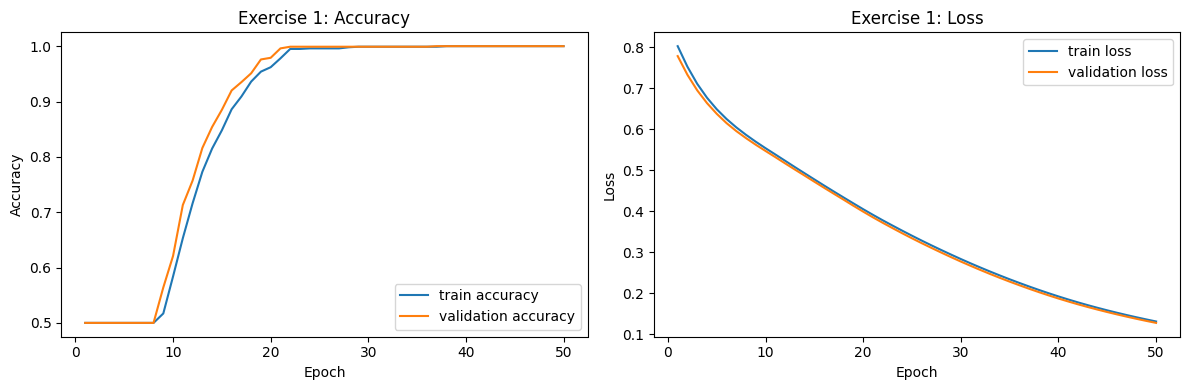

In [3]:
# Use the recorded history object from Keras to plot how both accuracy and loss
# evolve over the 50 training epochs.
epochs = np.arange(1, len(baseline_history.history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: classification accuracy for training and validation sets.
axes[0].plot(epochs, baseline_history.history["accuracy"], label="train accuracy")
axes[0].plot(epochs, baseline_history.history["val_accuracy"], label="validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Exercise 1: Accuracy")
axes[0].legend()

# Right panel: training and validation loss to check optimization behavior.
axes[1].plot(epochs, baseline_history.history["loss"], label="train loss")
axes[1].plot(epochs, baseline_history.history["val_loss"], label="validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Exercise 1: Loss")
axes[1].legend()

plt.tight_layout()
# plt.savefig("ex1_accuracy_loss.png", dpi=200, bbox_inches="tight")
plt.show()


**Exercise 1.4 answer.** The baseline model reached a final training accuracy of `1.0000` and a final validation accuracy of `1.0000`. The final validation loss was `0.1271`, and the validation accuracy first hit `100%` at epoch `37`.


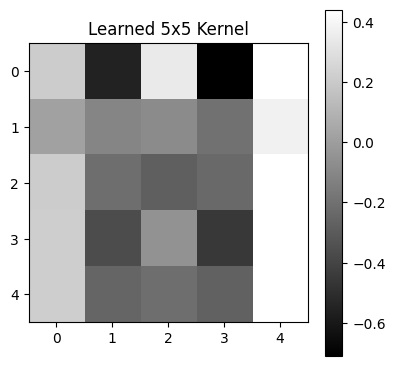

[[ 0.2089 -0.5544  0.3448 -0.7104  0.4404]
 [ 0.0144 -0.1082 -0.0844 -0.2005  0.3766]
 [ 0.2093 -0.2122 -0.2803 -0.2312  0.4406]
 [ 0.2164 -0.3685 -0.052  -0.456   0.4406]
 [ 0.2162 -0.2528 -0.2148 -0.2665  0.4402]]


In [4]:
# Display the single learned convolution kernel as a grayscale image so we can
# interpret which spatial pattern the network found useful.
plt.figure(figsize=(4.5, 4.5))
plt.imshow(baseline_kernel, cmap="gray")
plt.colorbar()
plt.title("Learned 5x5 Kernel")
# plt.savefig("ex1_kernel.png", dpi=200, bbox_inches="tight")
plt.show()

# Also print the numerical values for the write-up.
print(np.round(baseline_kernel, 4))


**Exercise 1.5 answer.** The kernel varies much more strongly by **column** than by row, so it is acting mainly as a detector of vertical structure. That is a reasonable outcome: vertical stripes create concentrated column-wise responses, and the global max-pooling layer can keep the strongest such response anywhere in the image. Horizontal stripes do not excite the filter in the same way.


In [5]:
# Compare the baseline model to the variants requested in the assignment:
# ReLU instead of linear activation, average pooling instead of max pooling,
# and different kernel sizes.
ex1_variants = [
    {"name": "relu_conv", "conv_activation": "relu", "pooling": "max", "kernel_size": 5, "seed": GLOBAL_SEED + 11},
    {"name": "average_pool", "conv_activation": "linear", "pooling": "average", "kernel_size": 5, "seed": GLOBAL_SEED + 12},
    {"name": "kernel_3", "conv_activation": "linear", "pooling": "max", "kernel_size": 3, "seed": GLOBAL_SEED + 13},
    {"name": "kernel_7", "conv_activation": "linear", "pooling": "max", "kernel_size": 7, "seed": GLOBAL_SEED + 14},
]

ex1_variant_results = {}
for variant in ex1_variants:
    # Re-train from scratch for each design choice so the comparison is fair.
    _, history = train_exercise_1_model(
        x_train,
        y_train,
        x_val,
        y_val,
        kernel_size=variant["kernel_size"],
        conv_activation=variant["conv_activation"],
        pooling=variant["pooling"],
        seed=variant["seed"],
    )
    ex1_variant_results[variant["name"]] = {
        "final_val_accuracy": history.history["val_accuracy"][-1],
        "final_val_loss": history.history["val_loss"][-1],
    }

ex1_variant_results


{'relu_conv': {'final_val_accuracy': 1.0,
  'final_val_loss': 0.20796847343444824},
 'average_pool': {'final_val_accuracy': 0.5889999866485596,
  'final_val_loss': 0.6920753717422485},
 'kernel_3': {'final_val_accuracy': 0.5, 'final_val_loss': 0.6922290921211243},
 'kernel_7': {'final_val_accuracy': 1.0,
  'final_val_loss': 0.07430224120616913}}

**Exercise 1.6 answer.**

- ReLU instead of linear still worked well: final validation accuracy was `1.000`, but the final validation loss increased to about `0.208`, so the model was less confident.
- Average pooling performed poorly: final validation accuracy was about `0.589`, which is close to chance. The averaging step suppresses the strongest local orientation response that max pooling preserves.
- A `3x3` kernel failed in this one-filter architecture: final validation accuracy was about `0.500`.
- A `7x7` kernel worked very well and gave the best final validation loss among the tested variants (`0.0743`), suggesting that the larger receptive field made orientation detection easier.


## Exercise 2


Initial cost: 1.3349391436004772
Final cost: 0.03853587871623123
Feature parameters:
[[ 6.3728 -3.5684]
 [-4.2981  2.8932]
 [-7.4979  1.707 ]]
Linear parameters:
[[-0.1521 -0.63  ]
 [-1.0066  0.5629]
 [-0.2575 -0.9997]]


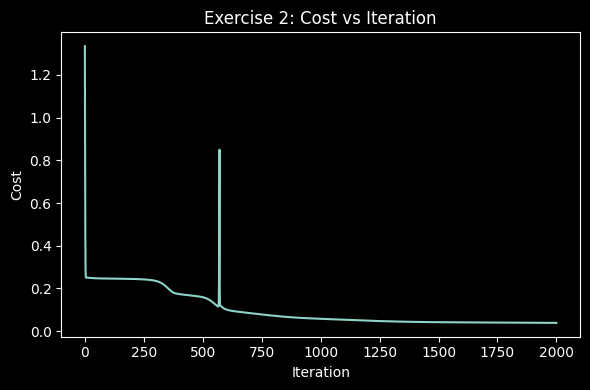

In [3]:
# The CSV stores two input coordinates in the first two rows and two output rows
# in the last two rows.
data = np.loadtxt(ROOT / "multiple_sine_waves.csv", delimiter=",")
x = data[:2, :]
y = data[2:, :]

rng = np.random.default_rng(GLOBAL_SEED)
best_w = None
best_history = None
best_cost = float("inf")

# Because the objective is non-convex, different initializations can converge to
# different local minima. I therefore keep the best run across 50 restarts.
for _ in range(50):
    init = rng.normal(scale=0.5, size=12)
    w_candidate, history = gradient_descent(exercise_2_cost, init, alpha=1.0, max_its=2000, x=x, y=y)
    if history[-1] < best_cost:
        best_cost = history[-1]
        best_w = w_candidate
        best_history = history

# Convert the best flat parameter vector back into its feature-layer and output-layer
# interpretations so the parameters can be reported clearly.
feature_params, linear_params = unpack_exercise_2_params(best_w)
print("Initial cost:", best_history[0])
print("Final cost:", best_history[-1])
print("Feature parameters:")
print(np.round(np.array(feature_params, dtype=float), 4))
print("Linear parameters:")
print(np.round(np.array(linear_params, dtype=float), 4))

# Plot the cost curve to show gradient descent converging.
plt.figure(figsize=(6, 4))
plt.plot(best_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Exercise 2: Cost vs Iteration")
plt.tight_layout()
# plt.savefig("ex2_cost_history.png", dpi=200, bbox_inches="tight")
plt.show()


**Exercise 2 answer.** Using full-batch gradient descent with `max_its = 2000` and `alpha = 1`, and keeping the best of 50 random restarts, the cost decreased from `1.3349` to `0.03854`.

The best parameters were

$$
W_f =
\begin{bmatrix}
 6.3728 & -3.5684 \\
-4.2981 &  2.8932 \\
-7.4979 &  1.7070
\end{bmatrix},
\qquad
W_\ell =
\begin{bmatrix}
-0.1521 & -0.6300 \\
-1.0066 &  0.5629 \\
-0.2575 & -0.9997
\end{bmatrix}.
$$

Here the columns of $W_f$ define the two sinusoidal hidden features, and $W_\ell$ is the linear readout to the two output rows of the dataset. Figure 10.7 in context is showing the learned sinusoidal features and the fitted outputs over the input space.


## Exercise 3


In [4]:
# Load MNIST once and reuse it across all model-tuning experiments.
train_images, train_labels = load_mnist()
learning_rates = [1.0, 0.5, 0.1, 0.01, 0.001]

lr_histories = {}
lr_summary = {}
for offset, lr in enumerate(learning_rates):
    # Re-train the same architecture at each learning rate so the effect of alpha
    # can be observed directly from the validation-loss curves.
    history = train_mnist_model(
        train_images,
        train_labels,
        model_kind="sweep",
        epochs=10,
        seed=GLOBAL_SEED + 100 + offset,
        learning_rate=lr,
    )
    lr_histories[lr] = history
    lr_summary[lr] = summarize_history(history)

lr_summary


{1.0: {'best_val_loss': 2.1434545516967773,
  'best_epoch': 9,
  'best_val_accuracy': 0.19300000369548798,
  'final_val_loss': 2.1921558380126953,
  'final_val_accuracy': 0.17341665923595428},
 0.5: {'best_val_loss': 1.7413551807403564,
  'best_epoch': 10,
  'best_val_accuracy': 0.3644999861717224,
  'final_val_loss': 1.7413551807403564,
  'final_val_accuracy': 0.35741665959358215},
 0.1: {'best_val_loss': 0.4784741997718811,
  'best_epoch': 8,
  'best_val_accuracy': 0.9277499914169312,
  'final_val_loss': 0.5496373772621155,
  'final_val_accuracy': 0.921833336353302},
 0.01: {'best_val_loss': 0.13858790695667267,
  'best_epoch': 1,
  'best_val_accuracy': 0.971916675567627,
  'final_val_loss': 0.26256486773490906,
  'final_val_accuracy': 0.9694166779518127},
 0.001: {'best_val_loss': 0.07494605332612991,
  'best_epoch': 6,
  'best_val_accuracy': 0.9782500267028809,
  'final_val_loss': 0.08032749593257904,
  'final_val_accuracy': 0.9782500267028809}}

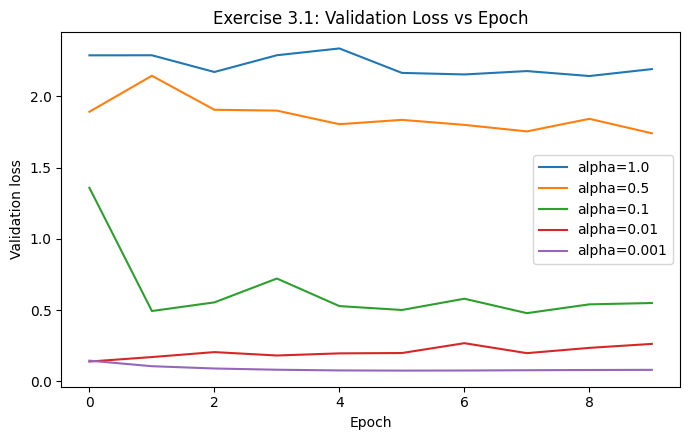

In [8]:
# Plot only validation loss here because that is the metric explicitly requested
# in Exercise 3.1 for comparing learning rates.
plt.figure(figsize=(7, 4.5))
for lr in learning_rates:
    plt.plot(lr_histories[lr].history["val_loss"], label=f"alpha={lr}")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Exercise 3.1: Validation Loss vs Epoch")
plt.legend()
plt.tight_layout()
# plt.savefig("ex3_learning_rate_sweep.png", dpi=200, bbox_inches="tight")
plt.show()


**Exercise 3.1 answer.**

Best validation results from the sweep:

| Learning rate | Best val. loss | Best epoch | Best val. accuracy |
| --- | ---: | ---: | ---: |
| 1.0 | 2.1435 | 9 | 0.1930 |
| 0.5 | 1.7414 | 10 | 0.3645 |
| 0.1 | 0.4785 | 8 | 0.9277 |
| 0.01 | 0.1386 | 1 | 0.9719 |
| 0.001 | 0.07495 | 6 | 0.9783 |

As the learning rate decreases, training becomes much more stable and the validation loss improves dramatically. `alpha = 1.0` is too large: the model stays close to chance performance and never settles. `alpha = 0.5` is still too aggressive. `alpha = 0.1` learns, but the validation curve oscillates. `alpha = 0.01` learns very quickly but reaches its best validation loss immediately, suggesting overshooting and early overfitting. Among these trials, `alpha = 0.001` is the best choice.


In [9]:
# Train the small model from Exercise 3.2, which is just multiclass logistic
# regression because there are no hidden layers.
small_history = train_mnist_model(
    train_images,
    train_labels,
    model_kind="small",
    epochs=50,
    seed=GLOBAL_SEED + 200,
)

# Summarize the best and final validation metrics to discuss overfitting.
small_summary = summarize_history(small_history)
small_summary


{'best_val_loss': 0.26352766156196594,
 'best_epoch': 24,
 'best_val_accuracy': 0.9307500123977661,
 'final_val_loss': 0.26692044734954834,
 'final_val_accuracy': 0.9292500019073486}

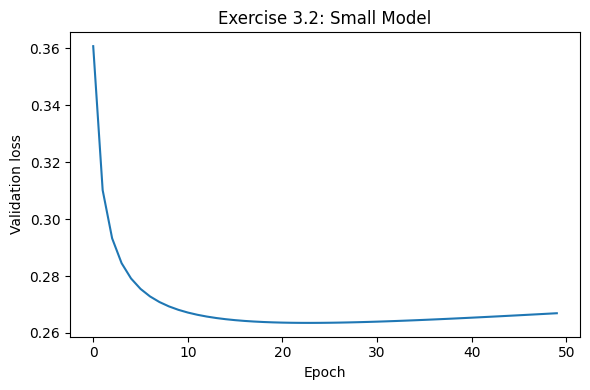

In [10]:
# Plot the small model's validation loss over time to look for a clear minimum.
plt.figure(figsize=(6, 4))
plt.plot(small_history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Exercise 3.2: Small Model")
plt.tight_layout()
# plt.savefig("ex3_small_model.png", dpi=200, bbox_inches="tight")
plt.show()


**Exercise 3.2 answer.** For the logistic-regression model, the best validation loss was `0.2635` at epoch `24`, while the final validation loss after 50 epochs was `0.2669`. That increase is very small, so there is **not** a sharp, well-defined overfitting threshold here. The minimum is broad and shallow.


In [11]:
# Train the larger model from Exercise 3.3 so we can compare its validation-loss
# behavior to the much smaller logistic-regression baseline.
large_history = train_mnist_model(
    train_images,
    train_labels,
    model_kind="large",
    epochs=50,
    seed=GLOBAL_SEED + 201,
)

# Again, keep the best epoch information for the written discussion.
large_summary = summarize_history(large_history)
large_summary


{'best_val_loss': 0.10384414345026016,
 'best_epoch': 8,
 'best_val_accuracy': 0.9786666631698608,
 'final_val_loss': 0.19578027725219727,
 'final_val_accuracy': 0.9785000085830688}

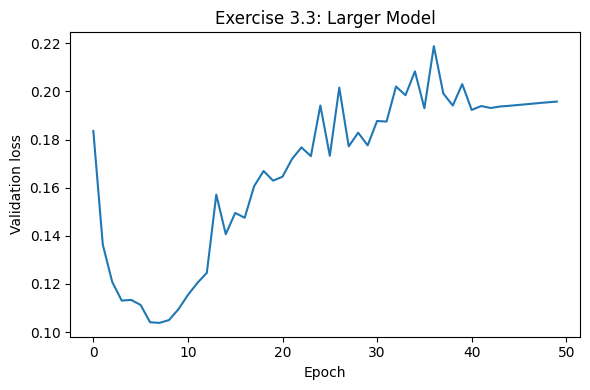

In [12]:
# The larger model should overfit more visibly, so the validation-loss curve is the
# main diagnostic plot for this exercise.
plt.figure(figsize=(6, 4))
plt.plot(large_history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Exercise 3.3: Larger Model")
plt.tight_layout()
# plt.savefig("ex3_large_model.png", dpi=200, bbox_inches="tight")
plt.show()


**Exercise 3.3 answer.** For the larger network, the best validation loss was `0.1038` at epoch `8`, but it increased to `0.1958` by epoch `50`. This model shows a much clearer overfitting region: after about epoch `8`, the model continues fitting the training data while validation loss degrades noticeably. The validation accuracy stays high, which is a good reminder that loss can reveal overconfident mistakes that accuracy hides.


## Exercise 4

Let

$$
\Phi =
\begin{bmatrix}
\phi(\mathbf{x}_1) & \phi(\mathbf{x}_2) & \cdots & \phi(\mathbf{x}_P)
\end{bmatrix}
\in \mathbb{R}^{M \times P},
\qquad
\mathbf{y} \in \mathbb{R}^P.
$$

The $l_2$-regularized least-squares objective is

$$
J(\mathbf{w}) = \frac{1}{2}\|\Phi^\top \mathbf{w} - \mathbf{y}\|_2^2 + \frac{\lambda}{2}\|\mathbf{w}\|_2^2.
$$

Setting the gradient to zero gives

$$
\Phi(\Phi^\top \mathbf{w} - \mathbf{y}) + \lambda \mathbf{w} = \mathbf{0},
$$

so

$$
(\Phi\Phi^\top + \lambda I)\mathbf{w} = \Phi\mathbf{y}.
$$

The right-hand side lies in the span of the training feature vectors, so write

$$
\mathbf{w} = \Phi\mathbf{a}.
$$

Substituting gives

$$
(\Phi\Phi^\top + \lambda I)\Phi\mathbf{a} = \Phi\mathbf{y}
\quad \Longrightarrow \quad
\Phi(\Phi^\top\Phi\mathbf{a} + \lambda\mathbf{a} - \mathbf{y}) = \mathbf{0}.
$$

Therefore

$$
(K + \lambda I)\mathbf{a} = \mathbf{y},
\qquad
K = \Phi^\top\Phi,
\qquad
K_{pq} = k(\mathbf{x}_p, \mathbf{x}_q).
$$

So the kernelized solution is

$$
\mathbf{a} = (K + \lambda I)^{-1}\mathbf{y},
\qquad
\mathbf{w} = \Phi(K + \lambda I)^{-1}\mathbf{y}.
$$

For a new point $\mathbf{x}$,

$$
\hat{y}(\mathbf{x}) = \mathbf{k}(\mathbf{x})^\top (K + \lambda I)^{-1}\mathbf{y},
$$

where

$$
\mathbf{k}(\mathbf{x}) =
\begin{bmatrix}
k(\mathbf{x}, \mathbf{x}_1) & \cdots & k(\mathbf{x}, \mathbf{x}_P)
\end{bmatrix}^\top.
$$

This is the $l_2$-regularized kernel least-squares regression formula.


## Exercise 5


In [13]:
# Reproduce the noisy sin(x) regression dataset from the assignment prompt.
rng = np.random.RandomState(1)
X = np.sort(6.3 * rng.rand(100, 1), axis=0)
y = np.sin(X).ravel()
y += 0.3 * (0.5 - rng.rand(len(X)))

# Fit scikit-learn's tree regressor at the two requested maximum depths.
regr_1 = DecisionTreeRegressor(max_depth=2, random_state=1)
regr_2 = DecisionTreeRegressor(max_depth=5, random_state=1)
regr_1.fit(X, y)
regr_2.fit(X, y)

sklearn_depth_2 = regr_1.predict(X)
sklearn_depth_5 = regr_2.predict(X)

# Run the custom recursive implementation on the same y-values. Since the custom
# code is designed only to predict at the sampled x-points, it returns one value
# per training input, matching the arrays above.
custom_depth_2 = run_custom_tree(y, max_depth=2)
custom_depth_5 = run_custom_tree(y, max_depth=5)

# The maximum absolute difference is a direct numerical check that the custom
# implementation agrees with scikit-learn on the sampled points.
print("max |sklearn - custom| at depth 2:", np.max(np.abs(sklearn_depth_2 - custom_depth_2)))
print("max |sklearn - custom| at depth 5:", np.max(np.abs(sklearn_depth_5 - custom_depth_5)))


max |sklearn - custom| at depth 2: 2.220446049250313e-16
max |sklearn - custom| at depth 5: 0.0


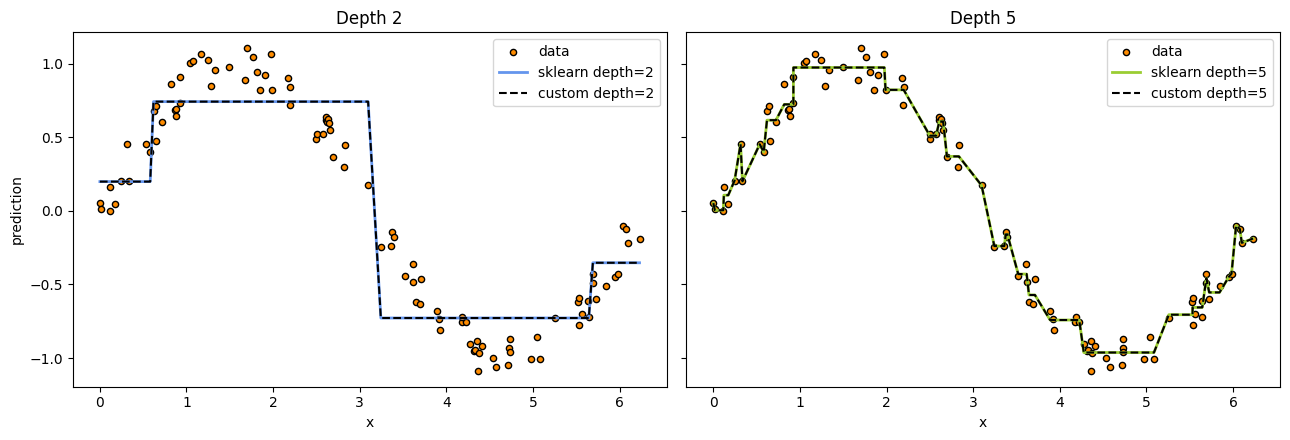

In [14]:
# Plot scikit-learn and custom predictions on top of the same noisy dataset so the
# agreement can be checked visually in addition to numerically.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

axes[0].scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
axes[0].plot(X, sklearn_depth_2, color="cornflowerblue", linewidth=2, label="sklearn depth=2")
axes[0].plot(X, custom_depth_2, color="black", linestyle="--", linewidth=1.5, label="custom depth=2")
axes[0].set_title("Depth 2")
axes[0].set_xlabel("x")
axes[0].set_ylabel("prediction")
axes[0].legend()

axes[1].scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
axes[1].plot(X, sklearn_depth_5, color="yellowgreen", linewidth=2, label="sklearn depth=5")
axes[1].plot(X, custom_depth_5, color="black", linestyle="--", linewidth=1.5, label="custom depth=5")
axes[1].set_title("Depth 5")
axes[1].set_xlabel("x")
axes[1].legend()

plt.tight_layout()
# plt.savefig("ex5_tree_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


**Exercise 5 answer.** The custom tree regressor matches scikit-learn on the sampled points to machine precision:

- depth 2: `2.22e-16`
- depth 5: `0.0`

So the implementation is correctly reproducing the same piecewise-constant regression values at the training inputs. The stopping rule for single-point intervals is handled by assigning the mean of that interval, which in the one-point case is just that point itself.
